# Text classification :: Spam detection

## Task 

We want to build a Spam detector which, given examples of spam emails (e.g. flagged by users) and examples of regular (non-spam, also called "ham") emails, learns how to flag new unseen emails as spam or non-spam.

## Data

We will use the [SpamAssassin](https://spamassassin.apache.org/) public email corpus. This dataset contains ~6'000 labeled emails with a ~30% spam ratio. If you want to learn more about this dataset, check [this](https://spamassassin.apache.org/old/publiccorpus/). (*Note: Datasets of text are called corpora and samples are called documents.*) 

The dataset has been downloaded for you and is available in the *data* folder.

## Notebook overview

* Load the data
* Text preprocessing
* Data exploration
* Feature extraction
* Build a spam detector
* What did our model learn? Error analysis

## 1. The data

In [1]:
# Load libraries and helper functions
import tools

In [2]:
# Load the data
df = tools.load_data()

Data loaded.
Data size: (5832, 2)


Let's check the number of samples per class in the data.

Samples per class (%):
non-spam    70.3
spam        29.7
Name: proportion, dtype: float64




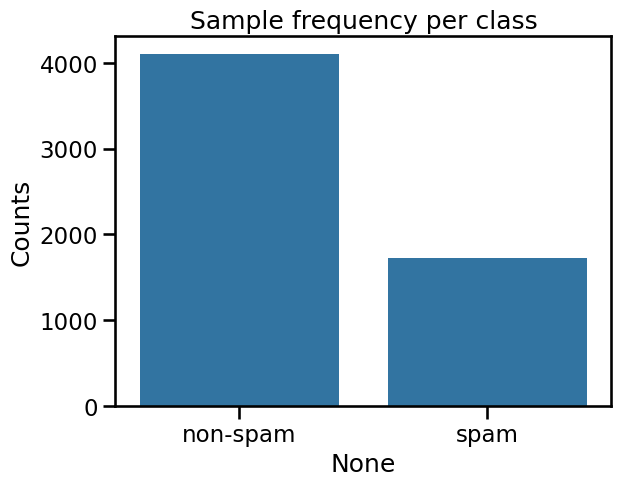

In [3]:
tools.plot_class_frequency(df)

Now, let's have a look at a few rows from the dataset.

***Note:*** The *label* is 0 for *non-spam* and 1 for *spam*.

In [4]:
# If you rerun this cell then you get a different set of samples displayed
df.sample(3)

,label,text
5819,0,"On Wed, 07 Aug 2002 01:38:55 -0400 Tom Lane <tgl@sss.pgh.pa.us> wrote: > I useta use mh-e regularly, but I never figured out whether it could > handle exmh's multidrop mechanism, which is something I've grown to > rely on. Does that work in recent mh-e versions? I'd love to use > mh-e when reading mail remotely, if it can handle my multiple-inbox- > folders setup... I've no idea. Have you tried asking on the MH-E lists? -- J C Lawrence ---------(*) Satan, oscillate my metallic sonatas. claw@kanga.nu He lived as a devil, eh? http://www.kanga.nu/~claw/ Evil is a name of a foeman, as I live. _______________________________________________ Exmh-users mailing list Exmh-users@redhat.com https://listman.redhat.com/mailman/listinfo/exmh-users"
1540,1,"<html> <body onLoad=""(window.open('http://66.231.133.201/nationwide/'))"" link=""#0000FF"" vlink=""#0000FF"" alink=""#0000FF""> <div align=""center""> <center> <table border=""1"" width=""600"" bordercolordark=""#000080"" cellspacing=""0"" bordercolor=""#000080"" bgcolor=""#FFFFCC""> <tr> <td width=""100%""> <table border=""0"" width=""100%"" cellspacing=""0"" cellpadding=""0""> <tr> <td width=""100%"" bgcolor=""#FFFFCC"" valign=""middle"" align=""center""> <p align=""center""><font face=""Arial Black"" size=""4"" color=""#0000FF""><br> </font><font face=""Arial Narrow"" color=""#0000FF"" size=""5""><b>Refinancing Your Mortgage May Be Easier Then You Think!</b></font></p> <p align=""center""><b><font face=""Arial Narrow"" color=""#D6321B"" size=""5"">Now that rates are down,&nbsp;<br> this may be a good time to start saving money!</font></b></p> <p align=""center""><font color=""#0000FF"" size=""2"" face=""Microsoft Sans Serif""><a href=""http://66.231.133.201/nationwide/"">Click here for all details</a></font></td> </tr> </table> <div align=""center""> <center> <table border=""0"" width=""100%"" cellspacing=""0"" cellpadding=""0""> <tr> <td width=""100%"" valign=""middle"" align=""center"" bordercolor=""#000000"" bgcolor=""#FFFFCC""><b><font face=""Arial Narrow"" size=""5"" color=""#0000FF"">Free Service for USA Homeowners!</font></b></td> </tr> </table> </center> </div> <div align=""center""> <center> <table border=""0"" width=""100%"" cellspacing=""0"" cellpadding=""0""> <tr> <td width=""100%"" bgcolor=""#000000""> <P align=center><b><font size=""3"" face=""Arial"" color=""#00FF00""><br> </font><font color=""#FFFFCC"" face=""Arial Narrow"" size=""4"">Whether your credit rating is A++ or you are &quot;credit challenged&quot;, we have many loan&nbsp;<br> programs through hundreds of aggressive lenders wanting to help you.&nbsp;</font></b></P> <div align=""center""> <center> <table border=""0"" width=""96%"" bgcolor=""#000000"" cellspacing=""0"" cellpadding=""0""> <tr> <td width=""100%""> <P align=left><b><font face=""Arial Narrow"" color=""#FFFF00"" size=""4"">Second Mortgages</font><font face=""Arial""..."
706,1,"<HTML> <BODY> OWN YOUR VERY OWN FREE CASINO AND SPORTSBOOK! EARNING POTENTIAL: $75-$150,000 + YEARLY P/T!! Toll Free: 1-866-522-8575 24hrs. International calls: 1-954-610-9386 Ted Koppel, Nightline... ""Not only is Internet Gambling already possible, already a modestly thrivi= ng Industry, it promises to become huge"" We create your very own Online Casino and Sportsbook Absolutely FREE!! You Receive the Highest Payouts! 25-50%, With Lifetime Residuals! Our marketing tools assist you in easily generating revenue . 100 people losing just $500 a month in your casino gives you $25,000 a mon= th!!! *If you are one of the first 25 people to call today, Receive a FREE marke= ting package! *Available in a limited number of area codes throughout the USA. *AVAILABLE ON A FIRST COME FIRST SERVE BASIS IN YOUR AREA. Toll Free 1-866-522-8575 24hrs. International calls: 954-610-9386 or email= your name and phone number to: mailto:respond_to_dave@excite.com?subject=3DMore-Info-$$$ U.S. News and World report on Internet gambling: ""A gold rush in Cyberspac= e."" PAYOUT SCH

## 2. Text preprocessing

Good text preprocessing is an essential part of every NLP project!

Our goal here is to build a model that distinguishes non-spam from spam. The idea here is to "clean" and "standardize" raw text before feeding it to our machine learning model. We need to keep as many "informative" words as possible, while discarding the "uniformative" ones. Removing unnecessary content, i.e. the "noise", from our texts will help to improve the accuracy of our models.

<div class="alert alert-success">
<h2>Questions</h2>
    
Take a few minutes to look at the raw text.
    
**Which parts of the text do you think should be removed to make it readable?**
    
**How could the parts we have removed be useful for the distinction of spam and non-spam?**
</div>

A few observations:

* HTML tags 
* URLs
* E-mail addresses
* Punctuation marks, digits (e.g. 2002, 1.1, ...)
* Multiple whitespace
* Case conversion (e.g. Dog vs dog, ...)
* English STOPWORDS (e.g. a, is, my, i, all, and, by...)
* ...

Check out the features created in the subsection **Spammish signatures** that account the number of occurences with in an email, e.g. how many HTML tags or URLs did find in the email.

The *clean_corpus* function below takes care of all of that!

In [5]:
df = tools.clean_corpus(df)

print("Data cleaned")

Data cleaned


Let's have a look at a few "cleaned" examples.

In [6]:
tools.show_clean_text(df)


Original document:

these are being advertised all over the UK/ Chief come-on seems to be to the same people who use
phones for text messaging--i.e. teenagers. "Hi, we're at the beach and I met this awesome guy--
here's his pic" Tom

Cleaned document:

advertised chief come people phones text messaging teenagers beach awesome heres


## 3. Data Exploration :: What makes spam distinct?

### 2.1 Frequent words

Which words distinguish spam from non-spam? Can we  identify the words in a text that are the most informative about its topic?

Let's find the most frequent words in spam and non-spam.

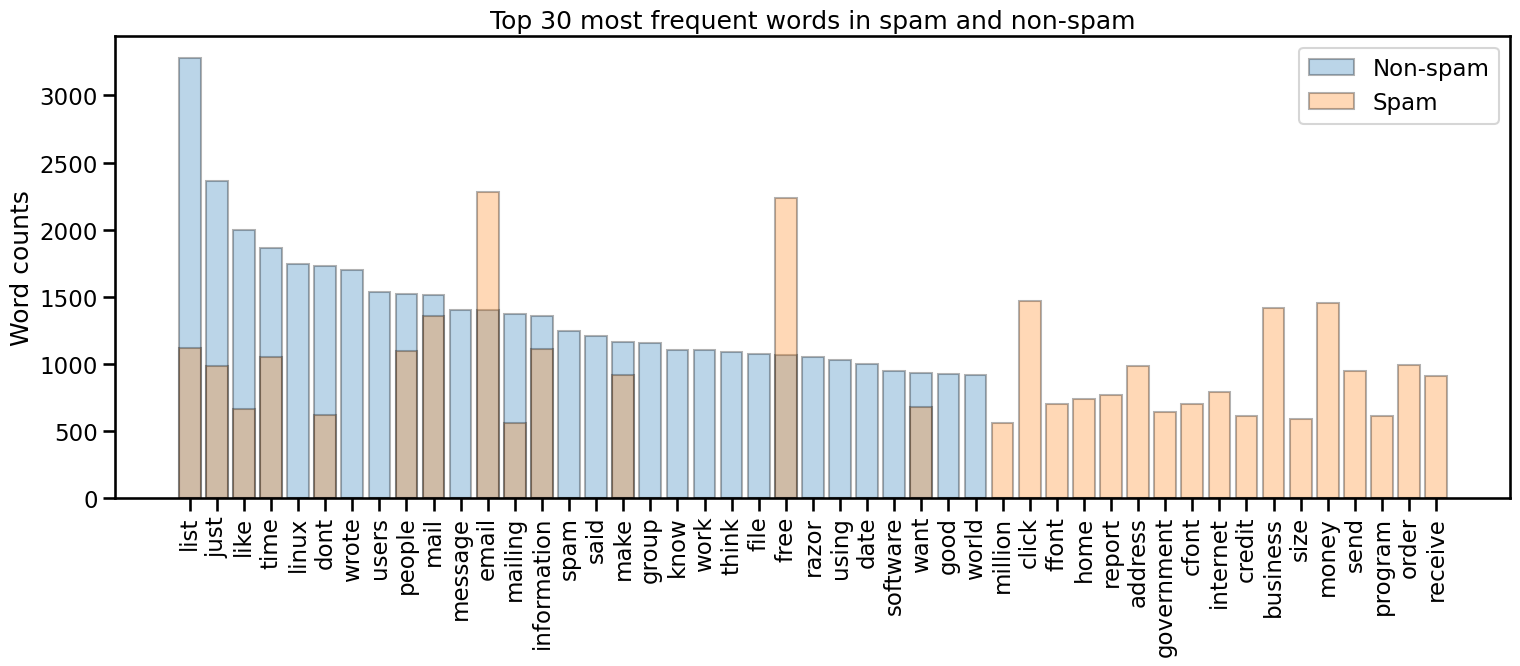

In [7]:
tools.plot_most_common_words(df=df, N=30)

<div class="alert alert-success">
<h3>Task 1</h3>
    
Change `N=30` and compare the outcome.
</div>

**Frequent "spammish" words**: 

* click
* money
* business
* free
* email
* ...

**Frequent "non-spammish" words**:
* list
* linux
* message
* wrote
* users
* spam
* said
* file
* good
* ...

### 2.2 What about "spammish" signatures?

* Do spams contain more HTML tags? 
* Does non-spam contain more URLs and E-mail adresses? 
* Are spams mails longer than non-spam? 
* ...

Let's find out!

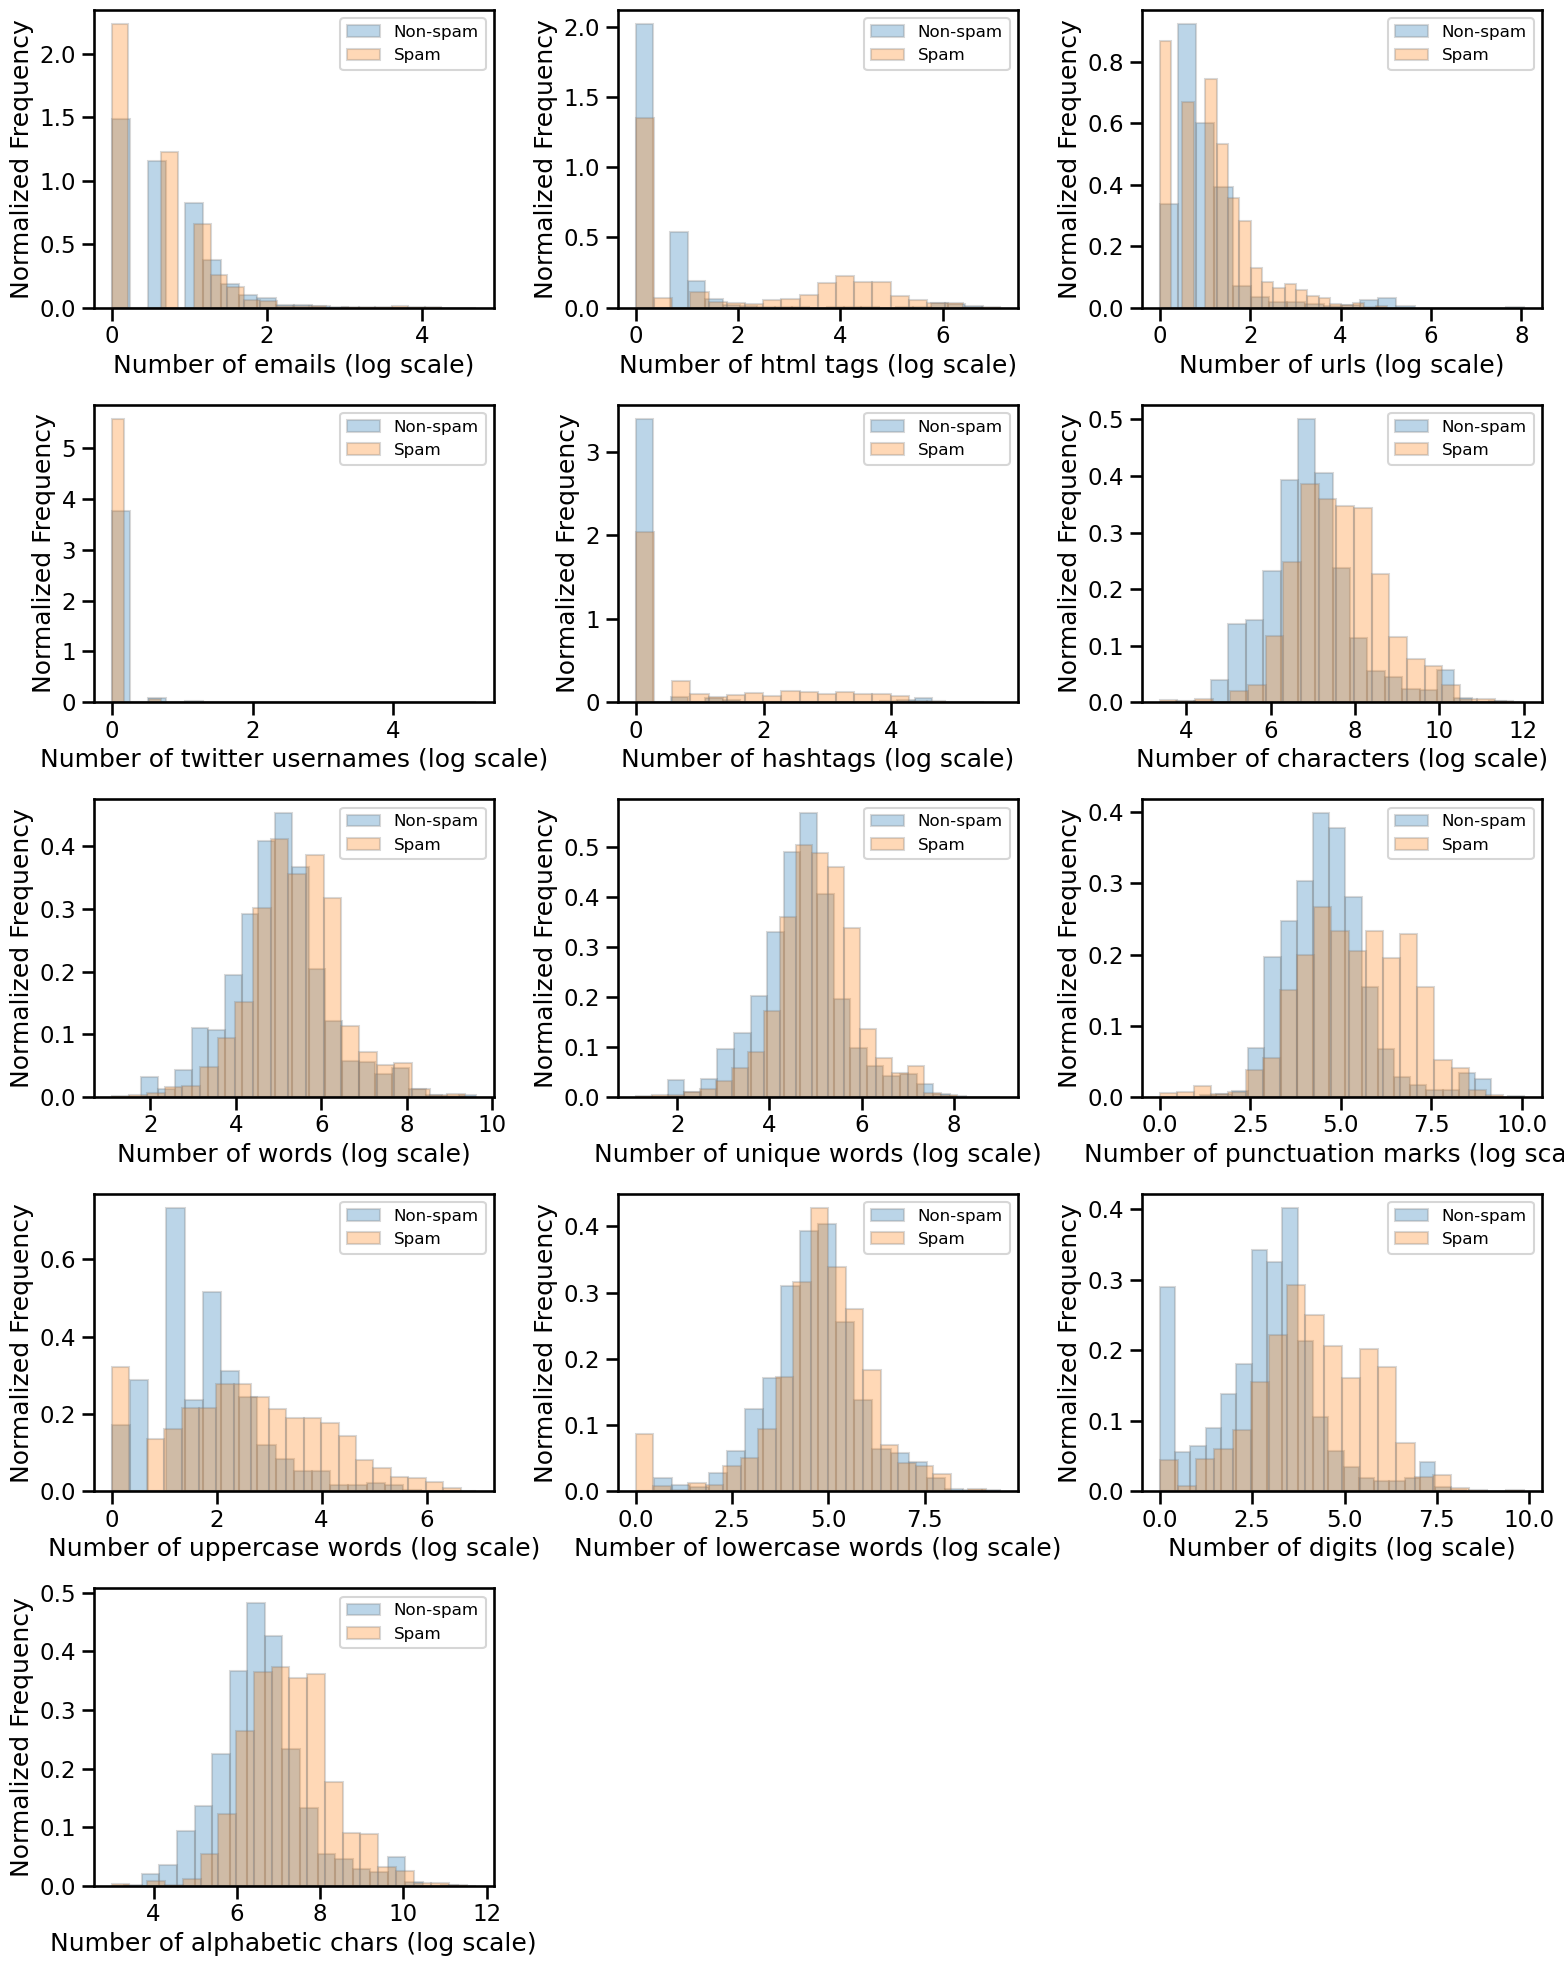

In [8]:
features = tools.get_features(df=df)

## 3. Feature engineering :: Extracting features from text

Computers don't understand natural language. So, how do we represent text?

One of the simplest but effective and commonly used models to represent text for machine learning is the ***Bag of Words*** model ([online documentation](https://en.wikipedia.org/wiki/Bag-of-words_model)). When using this model, we discard most of the structure of the input text (word order, chapters, paragraphs, sentences and formating) and only count how often each word appears in each text. Discarding the structure and counting only word occurencies leads to the mental image of representing text as a "bag".  

**Example:** Let our toy corpus contain four documents.

$ corpus = ['I\;enjoy\;paragliding.',  $  
$\hspace{2cm}'I\;like\;NLP.',$  
$\hspace{2cm}'I\;like\;deep\;learning.',$  
$\hspace{2cm}'O\;Captain!\;my\;Captain!']$ 

In [9]:
tools.show_bag_of_words_vector()

,captain,deep,enjoy,i,learning,like,my,nlp,o,paragliding
Text,,,,,,,,,,
I enjoy paragliding.,0,0,1,1,0,0,0,0,0,1
I like NLP.,0,0,0,1,0,1,0,1,0,0
I like deep learning.,0,1,0,1,1,1,0,0,0,0
O Captain! my Captain!,2,0,0,0,0,0,1,0,1,0


Bag of Words has converted all documents into numeric vectors. Each column represents a word from the corpus and each row one of the four documents. The value in each cell represents the number of times that word appears in a specific document. For example, the fourth document has the word `captain` occuring twice and the words `my` and `O` occuring once.

## 4. Build a spam detector

In the previous section, we saw how to perform text preprocessing and feature extraction from text. We are now ready to build our machine learning model for detecting spams. We will use a Logistic Regression classifier ([online documentation](https://en.wikipedia.org/wiki/Logistic_regression)).

First, we need to split the data into two sets: the `train` set and the `test` set. We will then use the train set to `fit` our model. The test set will be used to `evaluate` the performance of our model. 

### 4.1 Spam classification

<Axes: title={'center': 'Confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

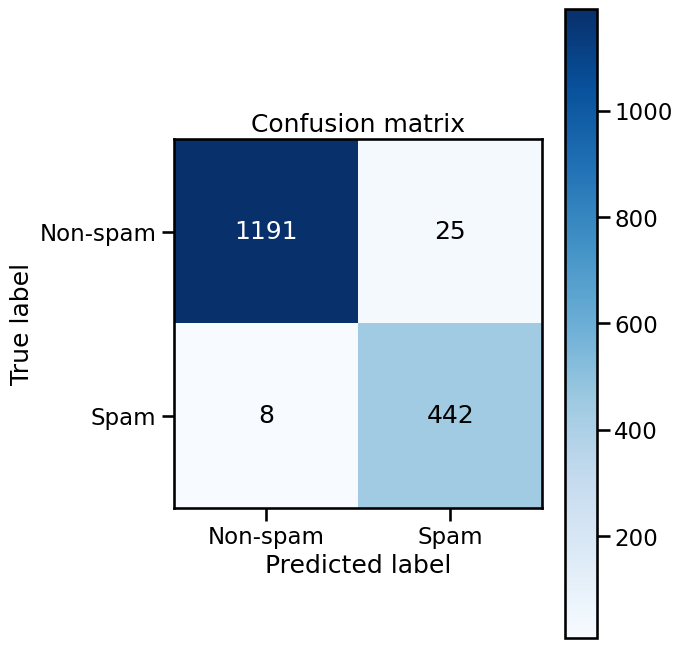

In [10]:
# Train/test splitting
df_train, df_test = tools.train_test_split_(df)

# Fit model on the train data
model = tools.fit_model(df_train)

# Print predictions on test set
tools.plot_confusion_matrix(df_test, model)

**Confusion matrices**  

Confusion matrices are a nice way of evaluating the performance of models for classification models. Rows correspond to the true classes and the columns to the predicted classes. Entries on the main diagonal of the confusion matrix correspond to correct predictions while the other cells tell us how many mistakes made our model ([online documentation]((https://en.wikipedia.org/wiki/Confusion_matrix))).

* The first row represents non-spam mails: 1'187 were correctly classified as 'non-spam', while 29 (~2,3%) were misclassified as 'spam'.
* The second row represents spam mails: 437 were correctly classified as 'spam', while 13 (~2,8%) were misclassified as 'non-spam'.

Our model did quite well!

### 4.2 What did our model learn from the data?

Our logistic regression model has learned which words are the most indicative of non-spam and which words are the most indicative of spam. The positive coefficients on the right correspond to words that, according to the model, are indicative of spam. The negative coefficients on the left correspond to words that, according to the model, are indicative of non-spam.

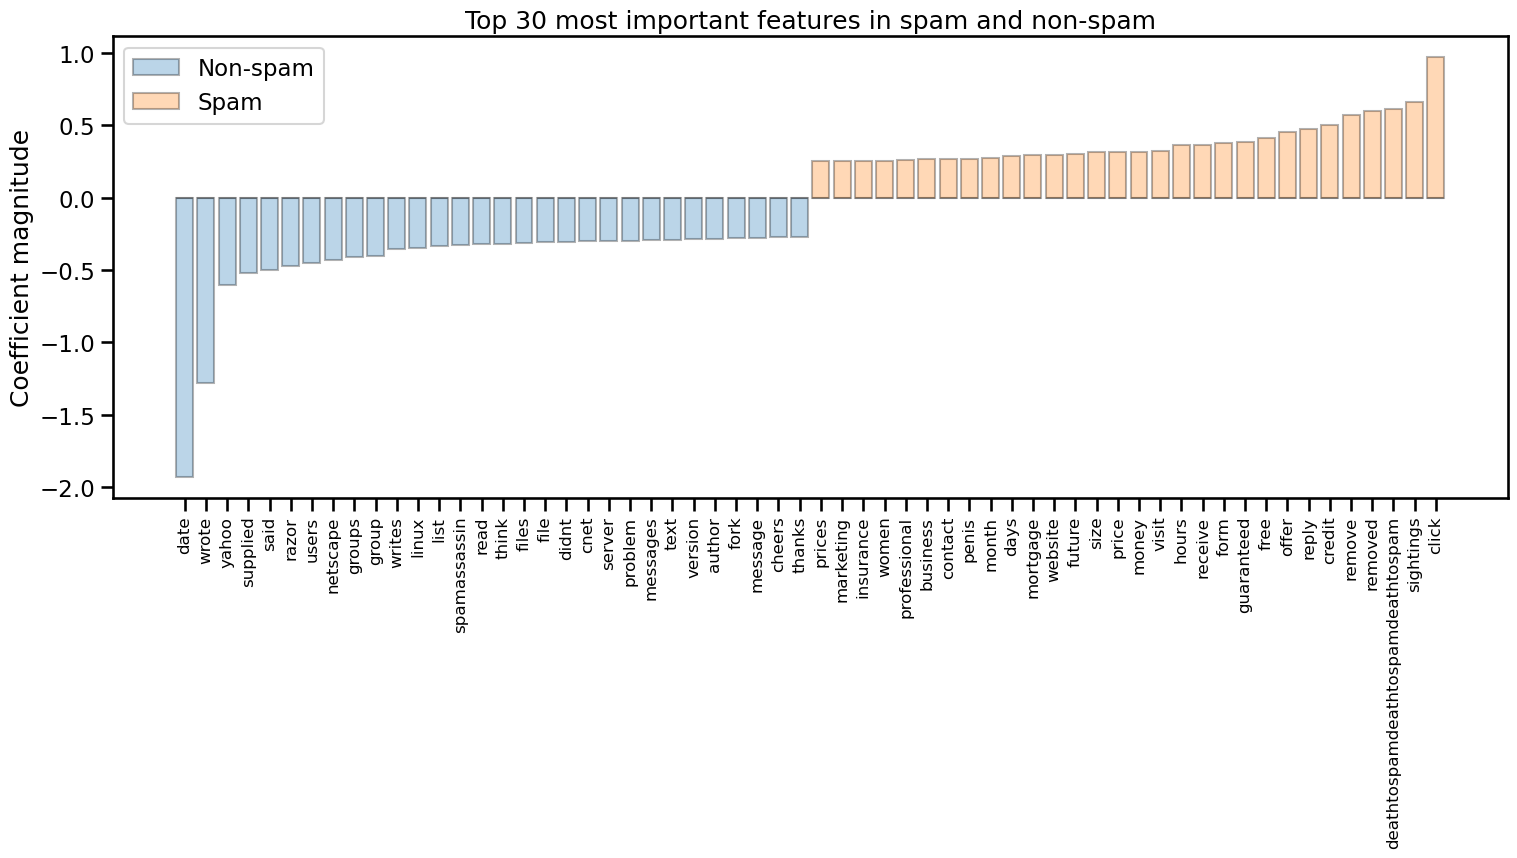

In [11]:
tools.visualize_coefficients(model, n_top_features=30)

According to the model, words such as "date", "wrote", "yahoo", "said", "linux", "author", ... are strong indicators of non-spam.  

Words such as "click", "credit", "remove", "free", "offer", "money" ... indicate spam. 

### 4.3 Error analysis :: Where does our model fail?

We will now analyze the misclassified mails in order to get some insights on where the model failed to make correct predictions. The *error_analysis* function below will show us the top features responsible for the model making a decision of prediction whether the mail is spam or non-spam.

Document index: 16 


Original Text
Dear Reader, How has Veuve Clicquot's sponsorship become so successful? Naomi Hancock,= =20 UK PR
Manager, tells us all about it in an exclusive interview. Also read= =20 about the launch of
SponsorRating, the first sponsorship rating agency,=20 our unsual transactions of the month, and a
"special X-treme" Sponsorship= =20 Alert. As this is the last issue for the summer, we wish you a
good August and=20 will be back in September. Your comments are always welcome, so please email us
at=20 news@sponsorclick.com. All our best, Rachael Mark Editor In this issue: 1. Sponsorship, How
and Why? Veuve Clicquot Speaks=20 2. Press Release: SponsorClick Launches the First Sponsorship
Ratin= g=20 Agency 3. Unusual Transactions of the Month 4. Sponsorship Alert Special X-treme 5.
Special Offers: Taylor Nelson Sofr=E8s, BVA, Sport+Markt,=20 Mediametrie, and more 6. More Matching
Opportunities With SponsorClick 7. How to Contact SponsorClick? =20 =20
---------------

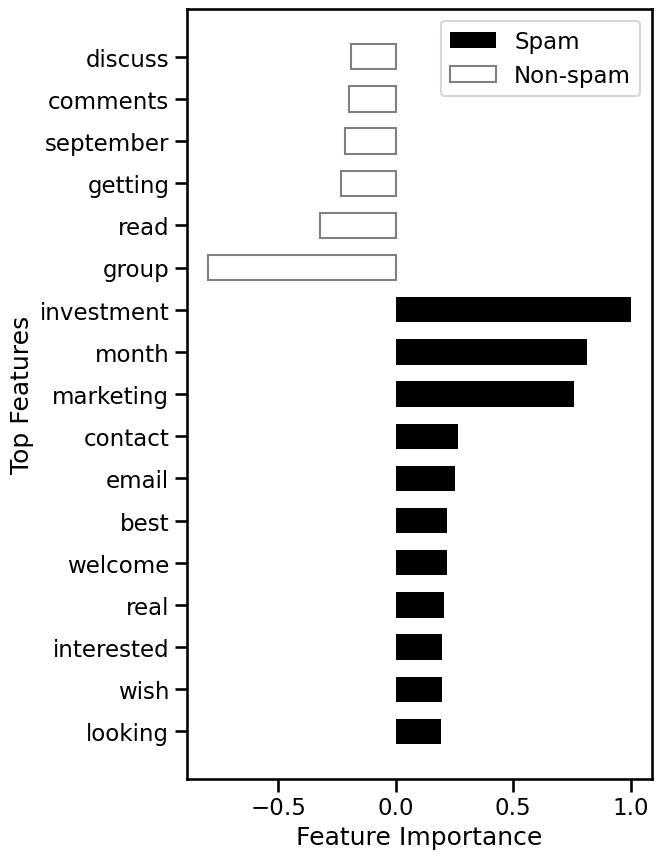

In [12]:
tools.error_analysis(df_test, model, doc_nbr=16)

<div class="alert alert-success">
<h3>Task 2</h3>
    
Let's change the `doc_nbr`.
</div>